In [1]:
import pandas as pd
from datetime import datetime
import re

def clean_yahoo_options_data(input_filename, output_filename, collection_date_str):
    print(f"Reading raw data from {input_filename}...")


    try:
        df = pd.read_csv(input_filename, sep=';')
    except Exception:

        df = pd.read_csv(input_filename, sep=',')


    collection_date = datetime.strptime(collection_date_str, '%Y-%m-%d')

    cleaned_rows = []

    for index, row in df.iterrows():
        contract_name = str(row['Contract Name'])


        match = re.search(r'[A-Z]+(\d{6})[CP]', contract_name)
        if not match:
            continue

        date_str = match.group(1)

        exp_date = datetime.strptime(date_str, '%y%m%d')


        days_to_maturity = (exp_date - collection_date).days


        strike = float(row['Strike'])


        iv_raw = str(row['Implied Volatility'])
        if iv_raw == 'nan' or iv_raw.strip() == '-':
            continue

        iv_clean = iv_raw.replace('%', '').replace(',', '')
        try:
            iv_decimal = float(iv_clean) / 100.0
        except ValueError:
            continue

        cleaned_rows.append({
            'DaysToMaturity': days_to_maturity,
            'Strike': strike,
            'ImpliedVolatility': iv_decimal
        })


    cleaned_df = pd.DataFrame(cleaned_rows)


    cleaned_df = cleaned_df.sort_values(by=['DaysToMaturity', 'Strike'])

    cleaned_df.to_csv(output_filename, index=False)




if __name__ == "__main__":

    clean_yahoo_options_data(
        input_filename="Data Call.csv",
        output_filename="cleaned_options.csv",
        collection_date_str="2024-06-07"
    )

Reading raw data from Data Call.csv...

Success! Cleaned 49 rows.
Data saved to cleaned_options.csv

Preview of the first 5 rows:
   DaysToMaturity  Strike  ImpliedVolatility
0             833   105.0             0.9666
1             833   110.0             0.9304
2             833   115.0             0.8928
3             833   120.0             0.8680
4             833   125.0             0.8252


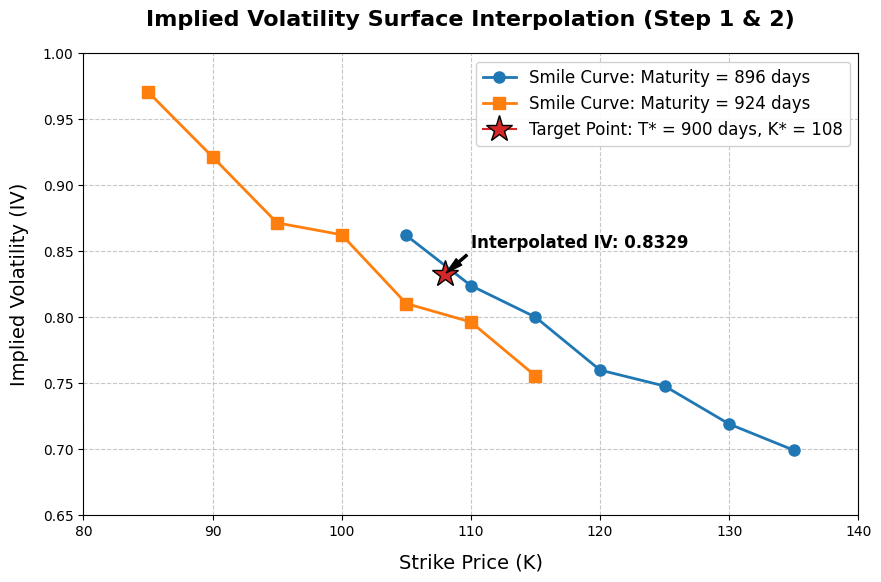

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("visualization_data.csv", sep=";")


df_896 = df[df['Maturity'] == 896.0]
df_924 = df[df['Maturity'] == 924.0]
df_target = df[df['Maturity'] == 900.0]


target_K = df_target['Strike'].iloc[0]
target_IV = df_target['ImpliedVolatility'].iloc[0]


plt.figure(figsize=(10, 6))
plt.style.use('default')


plt.plot(df_896['Strike'], df_896['ImpliedVolatility'],
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=8,
         label='Smile Curve: Maturity = 896 days')

plt.plot(df_924['Strike'], df_924['ImpliedVolatility'],
         marker='s', linestyle='-', linewidth=2, color='#ff7f0e', markersize=8,
         label='Smile Curve: Maturity = 924 days')


plt.plot(target_K, target_IV,
         marker='*', color='#d62728', markersize=20,
         markeredgecolor='black', markeredgewidth=1,
         label=f'Target Point: T* = 900 days, K* = {target_K}')


plt.annotate(f'Interpolated IV: {target_IV:.4f}',
             xy=(target_K, target_IV),
             xytext=(target_K + 2, target_IV + 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontsize=12, fontweight='bold')


plt.title('Implied Volatility Surface Interpolation (Step 1 & 2)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Strike Price (K)', fontsize=14, labelpad=10)
plt.ylabel('Implied Volatility (IV)', fontsize=14, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper right', framealpha=0.9)


plt.xlim(80, 140)
plt.ylim(0.65, 1.0)


filename = "volatility_smile_chart.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

